## **EDA Summary — Key Findings**

**Dataset:**
- Total tweets after cleaning: 61,822
- Train: 36,569 | Val: 7,599 | Test: 17,654

**Language Distribution:**
- Hausa dominates at 37.3% — model will perform best here
- Pidgin is least represented at 13.5%

**Label Distribution:**
- Overall labels are balanced — positive 34.5%, neutral 33.2%, negative 32.3%
- Pidgin neutral is severely imbalanced — only 72 samples vs 3,241 negative
- Class weights will be needed during training to handle Pidgin neutral

**Tweet Length:**
- Average: 17 words | Median: 14 words | Max: 74 words
- max_length = 64 chosen for tokenization

**Data Quality Issues Found and Fixed:**
- 512 duplicate tweets removed from train
- 34 duplicate tweets removed from val
- 926 tweets overlapping between train and test removed from train
- 256 tweets overlapping between val and test removed from val
- Test set kept untouched as ground truth throughout

**Observations:**
- URLs present — will be removed in preprocessing
- @user mentions already anonymised
- Yorùbá diacritics present — will be preserved
- Emojis present — removed for Logistic Regression, kept for deep learning models
- Pidgin shows heavy code-switching between English and Nigerian languages

In [1]:
# import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the datasets into train, validation and test dataframe
languages = {
    'hausa' : 'hau',
    'igbo': 'ibo',
    'pidgin': 'pcm',
    'yoruba': 'yor'
}

df_train_all = []
df_val_all = []
df_test_all = []

splits = ['train', 'dev', 'test']

for split in splits:
    for lang, folder in languages.items():
            df = pd.read_csv(f'../01-data/01-raw/{folder}/{split}.tsv' , sep='\t' )
            df['language'] = lang

            if split == "train":
                df_train_all.append(df)
            elif split == "dev":
                 df_val_all.append(df)
            elif split == "test":
                 df_test_all.append(df)

df_train = pd.concat(df_train_all, ignore_index=True)
df_val = pd.concat(df_val_all, ignore_index=True)
df_test = pd.concat(df_test_all, ignore_index=True)

In [3]:
# Check the shape of df_train, df_val, df_test
# How many tweets total across all splits

print(f'shape of train set: {df_train.shape} \nshape of validation set: {df_val.shape} \nshape of test set: {df_test.shape}')


shape of train set: (38007, 3) 
shape of validation set: (7889, 3) 
shape of test set: (17654, 3)


In [4]:
# Tweets per language
# Is the dataset balanced across languages?

df_train['language'].value_counts(normalize=True)

language
hausa     0.372879
igbo      0.268161
yoruba    0.224222
pidgin    0.134738
Name: proportion, dtype: float64

In [5]:
# Label distribution, check the distribution of positive, negative and neutral

df_train['label'].value_counts(normalize=True)

label
positive    0.345226
neutral     0.331518
negative    0.323256
Name: proportion, dtype: float64

In [6]:
# Group by language and label
# Some languages may be more imbalanced than others

df_train.groupby(['language', 'label']).size()

language  label   
hausa     negative    4573
          neutral     4912
          positive    4687
igbo      negative    2600
          neutral     4508
          positive    3084
pidgin    negative    3241
          neutral       72
          positive    1808
yoruba    negative    1872
          neutral     3108
          positive    3542
dtype: int64


- Pidgin neutral class has severe imbalance — only 72 samples
- This will affect model performance on Pidgin neutral predictions
- Mitigation: use class weights during training

In [7]:
# create a new column called tweet length

df_train['tweet_length'] = df_train['tweet'].str.split().str.len()

In [8]:
df_train['tweet_length'].describe()

count    38007.000000
mean        16.822191
std         11.278259
min          3.000000
25%          8.000000
50%         14.000000
75%         22.000000
max         74.000000
Name: tweet_length, dtype: float64

- Most tweets are short — median of 14 words
- 75% are under 22 words
- The max of 74 is likely one or two outliers

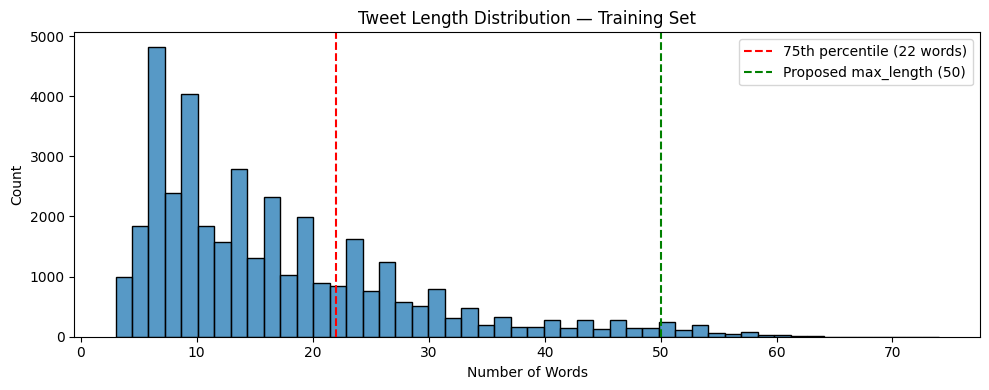

In [9]:
plt.figure(figsize=(10, 4))
sns.histplot(df_train['tweet_length'], bins=50)
plt.title('Tweet Length Distribution — Training Set')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.axvline(x=22, color='red', linestyle='--', label='75th percentile (22 words)')
plt.axvline(x=50, color='green', linestyle='--', label='Proposed max_length (50)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# check the null values for the train, val and test sets
print("Train nulls:")
print(df_train.isnull().sum())
print("\nVal nulls:")
print(df_val.isnull().sum())
print("\nTest nulls:")
print(df_test.isnull().sum())

Train nulls:
tweet           0
label           0
language        0
tweet_length    0
dtype: int64

Val nulls:
tweet       0
label       0
language    0
dtype: int64

Test nulls:
tweet       0
label       0
language    0
dtype: int64


In [11]:
# let us check for duplicates
df_train.duplicated(subset=['tweet']).sum()

np.int64(512)

In [12]:
# Check before
print(f"Before dropping duplicates: {df_train.shape}")

# Drop duplicates based on tweet text only
df_train = df_train.drop_duplicates(subset=['tweet'])

# Check after
print(f"After dropping duplicates: {df_train.shape}")

Before dropping duplicates: (38007, 4)
After dropping duplicates: (37495, 4)


In [13]:
print(f"Val duplicates:  {df_val.duplicated(subset=['tweet']).sum()}")
print(f"Test duplicates: {df_test.duplicated(subset=['tweet']).sum()}")

Val duplicates:  34
Test duplicates: 0


In [14]:
# check for tweets that appear in both train and test sets
overlap = set(df_train['tweet']).intersection(set(df_test['tweet']))
print(f"Tweets appearing in both train and test: {len(overlap)}")

Tweets appearing in both train and test: 926


In [15]:
# 1. Drop duplicates in val
df_val = df_val.drop_duplicates(subset=['tweet'])
print(f"Val after dedup: {df_val.shape}")

# 2. Remove train/test overlap from train
# Keep test clean — remove the overlapping tweets from train instead
overlap = set(df_train['tweet']).intersection(set(df_test['tweet']))
df_train = df_train[~df_train['tweet'].isin(overlap)]
print(f"Train after removing test overlap: {df_train.shape}")

# 3. Also check val/test overlap
val_test_overlap = set(df_val['tweet']).intersection(set(df_test['tweet']))
print(f"Val/Test overlap: {len(val_test_overlap)}")
df_val = df_val[~df_val['tweet'].isin(val_test_overlap)]
print(f"Val after removing test overlap: {df_val.shape}")

Val after dedup: (7855, 3)
Train after removing test overlap: (36569, 4)
Val/Test overlap: 256
Val after removing test overlap: (7599, 3)


**Findings: Data leakage detected**
- 926 tweets overlap between train and test
- 256 tweets overlap between val and test
- All overlapping tweets removed from train and val
- Test set kept clean as ground truth
- Final clean sizes: Train=36,569 | Val=7,599 | Test=17,654

In [16]:
for lang in ['hausa', 'igbo', 'pidgin', 'yoruba']:
    print(f"\n{'='*50}")
    print(f"Language: {lang.upper()}")
    print(f"{'='*50}")
    for label in ['positive', 'negative']:
        sample = df_train[(df_train['language'] == lang) & 
                          (df_train['label'] == label)].sample(1)['tweet'].values[0]
        print(f"\n{label.upper()}:")
        print(sample)


Language: HAUSA

POSITIVE:
@user @user Ubangiji Allah ya yi masa rahma Ya kyauta namu karshen🙏

NEGATIVE:
@user @user Zai dade yana Allah wadai😂😂😂

Language: IGBO

POSITIVE:
#WePraise ♫ Obuli we’m elu Higher higher Obuli We’m elu Higher higher Ah eh… ah eh… ah eh.. Onyekeruwa di ho

NEGATIVE:
@user @user @user 😂😂 nekwa nu m anya no be small🤣🤣

Language: PIDGIN

POSITIVE:
this midfield go make sense e fit carry us for the whole season paul pogba bruno fernandes fred scott mctominay nemanja matic donny van de beek if anybody woundjure we no go feel am

NEGATIVE:
omo josh e be like say i don jinx am o our light don spoil since yesterday evening

Language: YORUBA

POSITIVE:
Iba Gani Abiodun Ige Adams Aare Ona Kakanfo of Yoruba land @user the Installation of Princess Toyin Kolade Iyalaje Oodua Held Today at Ile Ife Osun State. #oodua #odua #yoruba https://t.co/qYgeRtfO82

NEGATIVE:
Ẹ wo #4GB #USB tó jẹ́ pé owó iyebíye àti títóbi gòdògbà ni tẹ́lẹ̀ rí. Ó wá di nkan kékeré tí wọ́n nhá lọ́fẹ̀ẹ

In [17]:
df_train.to_csv('../01-data/02-processed/train_clean.csv', index=False)
df_val.to_csv('../01-data/02-processed/val_clean.csv', index=False)
df_test.to_csv('../01-data/02-processed/test_clean.csv', index=False)

print("Cleaned data saved successfully")

Cleaned data saved successfully
